In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from functools import partial
from scipy.optimize import minimize
import pandas as pd
import random
import matplotlib
import pointpats

# Гауссовские процессы


*вариант 1*

1. Моделировать броуновское движение а) с помощью случайного блуждания с нормальными шагами, б) Построить частичные суммы в представлении Винера (в виде тригонометрических сумм) для броуновского движения. Проверить, что полученный вторым путем процесс имеет независимые нормальные приращения – измерить значения процесса в моменты i/n, найти приращения, построить ЭФР и проверить ее на нормальность.

In [4]:
def model_brownian_motion_rw(section = [0,1], num_steps = 1000, output = True):
    [a,b] = section
    len_step = (b-a)/num_steps
    points = np.arange(num_steps+1)/num_steps
    steps = stats.norm.rvs(scale = np.sqrt(len_step), size = num_steps)
    wt = np.cumsum(steps)
    wt = np.insert(wt, 0, 0)
    #wt = np.concatenate(np.zeros(1), wt)
    if output:
        plt.plot(points, wt, color = 'red')
        plt.title(f'Brownian motion as a random walk')
        plt.show()
    return wt



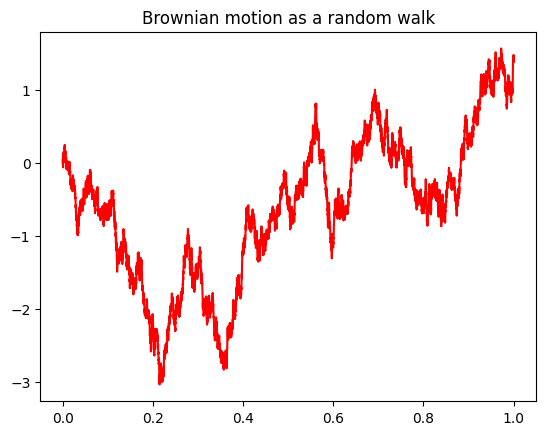

array([0.        , 0.0548484 , 0.04000236, ..., 1.43951057, 1.43419146,
       1.38063777], shape=(10001,))

In [22]:
model_brownian_motion_rw(section = [0,10], num_steps = 10000)

![Представление Винера](wiener_bm.png)

In [5]:
def model_bm_wiener(max_n = 1000, num_points = 1000, output = True):
    xi = stats.norm.rvs(size = max_n)
    
    def wt(t):
        return np.sum([xi[i-1]*(np.sqrt(2)*np.sin(np.pi*(i-0.5)*t))/(np.pi*(i-0.5)) for i in range(1,max_n+1)])
    
    if output:
        points = np.arange(0,num_points+1)/num_points
        y = [wt(x) for x in points]
        plt.plot(points, y)
        plt.title(f'Brownian motion with Wiener functions')
        plt.show()

    return wt

    

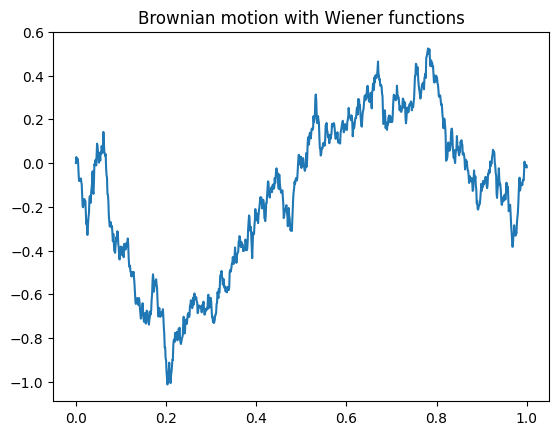

<function __main__.model_bm_wiener.<locals>.wt(t)>

In [29]:
model_bm_wiener()

In [6]:
def check_normality(n = 100, num_sim = 100):
    p_value = np.zeros(num_sim)
    for sim in range(num_sim):
        wt = model_bm_wiener(output=False)
        data = [wt(i/n) for i in range(n+1)]
        delta = [data[i+1]-data[i] for i in range(n)]
        p_value[sim]=stats.shapiro(delta)[1]
        print(p_value)
    sns.ecdfplot(p_value, label ='p-value ECDF for normality')
    x = np.linspace(0,1,1000)
    plt.plot(x,x, linestyle='--', color = 'black')
    plt.legend()
    plt.title('Checking the hypothesis of normality')
    plt.show()



[0.50227765]


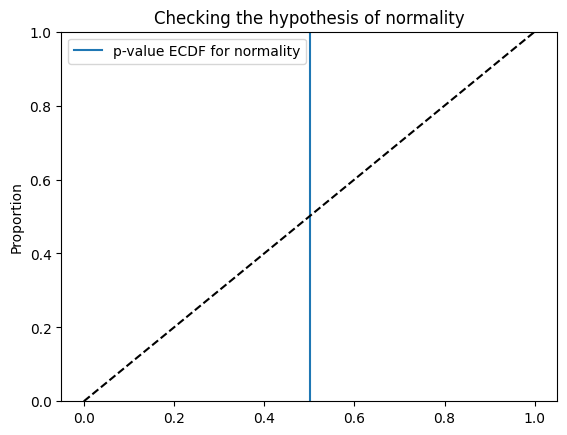

In [7]:
check_normality(num_sim=1)

2. Моделировать Wct/√c, tW1/t и сравнить с траекторией броуновского движения.

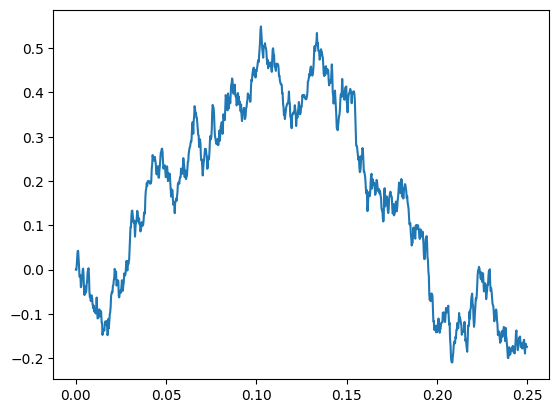

In [5]:
wt = model_bm_wiener(output=False)
num_points = 1000
c = 4
points = np.arange(0,num_points)/(c*num_points)
def wct(t):
    return wt(c*t)/np.sqrt(c)

y = [wct(i) for i in points]
plt.plot(points, y)
plt.show()

In [6]:
def model_bm_longterm(n = 1000, output = True ,num_points = 1000):
    wt_n = []
    wt_end = np.zeros(n+1)
    prev_end = 0

    for i in range(n):
        wt_n.append(model_bm_wiener(max_n = 1000, output = False))
        wt_end[i+1] = prev_end+wt_n[i](1)
        prev_end = wt_end[i+1]

    def wt(t):
        k = int(t)
        if k >= n:
            return wt_end[-1]
        return wt_n[k](t-int(t)) + wt_end[k]

    if output:
        points_demo = np.arange(num_points+1)*n/num_points
        y_demo = [wt(k) for k in points_demo]
        plt.plot(points_demo, y_demo)
        plt.title(f'Wt for t in [{0}, {num_points}]')
        plt.show()

    return wt

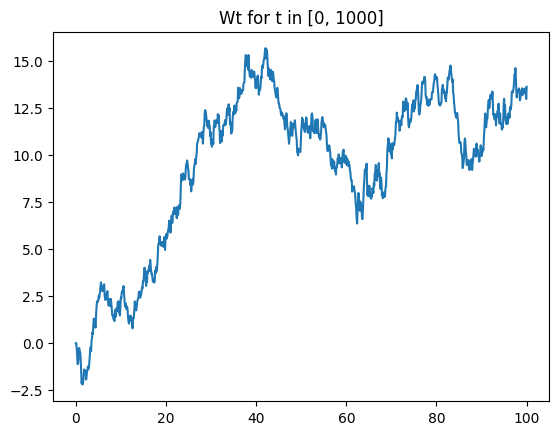

<function __main__.model_bm_longterm.<locals>.wt(t)>

In [25]:
model_bm_longterm(n=100)

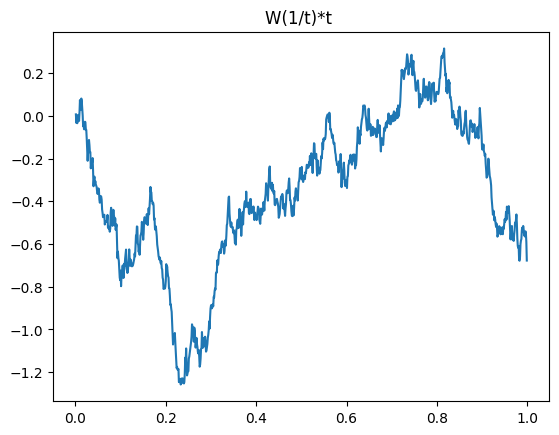

In [26]:
num_points = 1000

wt = model_bm_longterm(n = num_points, output=False)

t = np.arange(1,num_points)/num_points
wt_new = [wt(1/ti)*ti for ti in t]
plt.plot(t, wt_new)
plt.title('W(1/t)*t ')
plt.show()


3. Построить траекторию броуновского движения, i) броуновского моста, ii) броуновской извилины и iii)
броуновской экскурсии, используя то, что:

• фрагмент броуновского движения от 0 до последнего нуля τ0 совпадает по распределению (после
растяжения) с броуновским мостом;

• фрагмент броуновского движения от τ0 до 1 совпадает по распределению (после растяжения) с
броуновской извилиной.

• фрагмент броуновского движения от τ0 до первого нуля после точки 1 совпадает по распределению
(после растяжения) с броуновской экскурсией

Под растяжением подразумевается, что траектория растягивается по горизонтали в c раз до длины 1 и по вертикали в √c раз.

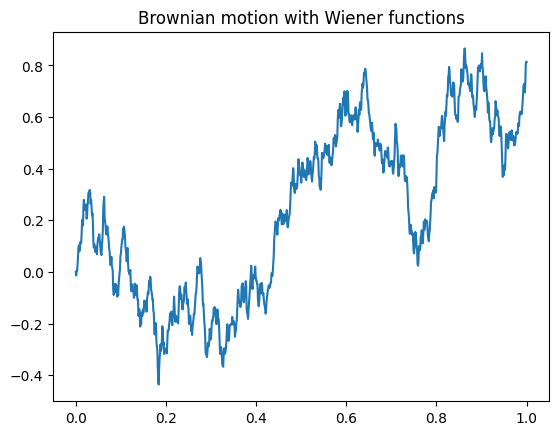

-0.01363030026310398


In [7]:
wt = model_bm_wiener()
points = np.arange(0,num_points)/num_points
print(wt(points[1]))

0.3065


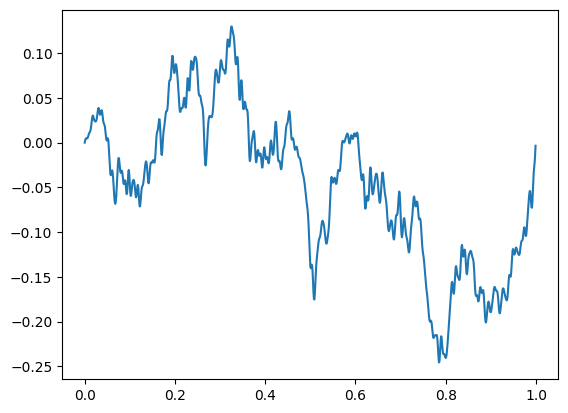

In [ ]:
num_points = 1000
wt = model_bm_wiener(output = False)
points = np.arange(0,num_points)/num_points
for ind in range(num_points-1, 1, -1):
    if wt(points[ind])*wt(points[ind-1]) <= 0:
        tau = (points[ind] + points[ind-1])/2
        break
print(tau)
t = np.arange(0,num_points)/num_points
wt0 = [wt(ti*tau)*np.sqrt(tau) for ti in t]   
plt.plot(t, wt0)    



4. Исследовать закон арксинуса для i) последнего пересечения нуля ii) момента достижения максимума
iii) время выше оси для случайного блуждания с шагами а) N (0, 1), б) (1) − 1.

In [28]:
n = 100

def generate_rw(x_gen, len = 100):
    # take generator for x -> return S_n trajectory
    x = x_gen(size = len)
    s = np.cumsum(x)
    s = np.concatenate(([0], s))
    return s

def get_last_zero(s):
    last = 0
    for k in range(1, len(s)):
        if s[k] == 0:
            last = k
        elif s[k]*s[k-1]<0:
            last = k - 1/2

    return last

def arcsine_law(x_gen, char, n = 100, title = None,k = 100):
    occ  =[]
    for _ in range(k):
        s = generate_rw(x_gen, len = n)
        occ.append(char(s)/n)
    plt.hist(occ, density=True, color = 'forestgreen', bins = int(n/10))
    x = np.linspace(0,1,1000)
    plt.plot(x, 1/(np.pi*np.sqrt(x*(1-x))), color = 'crimson')
    plt.title(title)
    plt.show()



C:\Users\NEKDAR\AppData\Local\Temp\ipykernel_15840\1801254337.py:27: RuntimeWarning: divide by zero encountered in divide
  plt.plot(x, 1/(np.pi*np.sqrt(x*(1-x))), color = 'crimson')


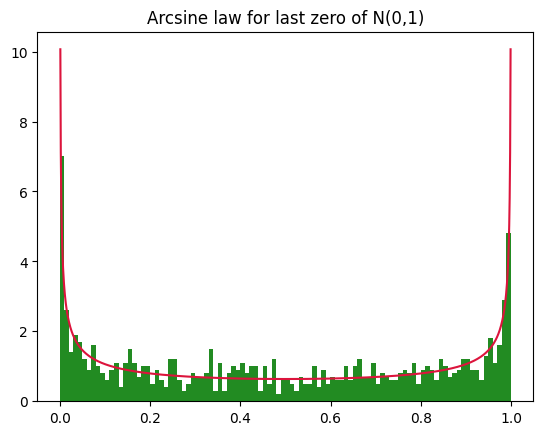

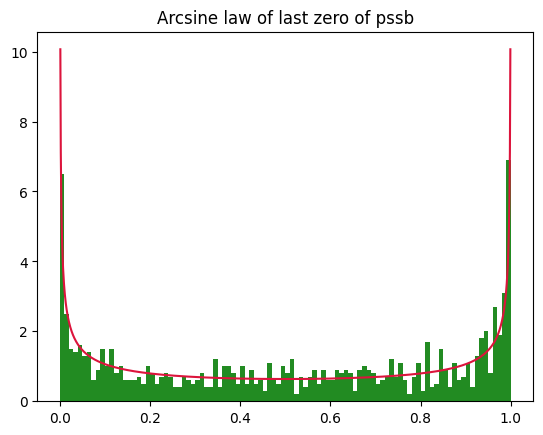

In [29]:
arcsine_law(stats.norm.rvs, get_last_zero, n = 1000, title='Arcsine law for last zero of N(0,1)',k=1000)
arcsine_law(partial(np.random.choice, a=[-1,1]), get_last_zero, n=1000, title='Arcsine law of last zero of pssb',k=1000)

5. *Исследовать распределение времени, проведенного выше оси броуновским мостом, используя случайное блуждание, возвращающееся в ноль (как эффективно моделировать такое блуждание?).

In [10]:
# используем представление броуновского моста как Wt-t*W1

def model_brownian_bridge(num_points = 1000, output = False):
    wt = model_brownian_motion_rw(num_steps = num_points, output=False)
    wt0 = [wt[i] - i/num_points*wt[-1] for i in range(num_points+1)]

    if output:
        points = np.arange(0,num_points+1)/num_points
        plt.plot(points, wt0)
        plt.title(f'Brownian bridge as a random walk')
        plt.axhline(y = 0, linestyle='--', color = 'black')
        plt.show()
    return wt0
    
def get_above_zero(s):
    count = 0
    for k in range(len(s) - 1):
        if s[k] >=0 and s[k+1]>=0:
            count += 1
    return count

def above_law_bm(num_sim = 1000, num_points = 1000):
    occ = []
    for _ in range(num_sim):
        wt = model_brownian_bridge(num_points = num_points)
        occ.append(get_above_zero(wt)/num_points)

    plt.hist(occ, density=True, color = 'forestgreen')
    x = np.linspace(0,1,1000)
    #plt.plot(x, 1/(np.pi*np.sqrt(x*(1-x))), color = 'crimson')
    plt.title(f'Above zero for brownian bridge')
    plt.show()

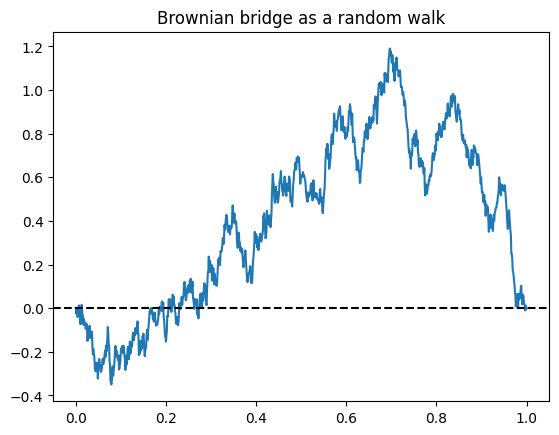

In [37]:
wt0 = model_brownian_bridge(output=True)

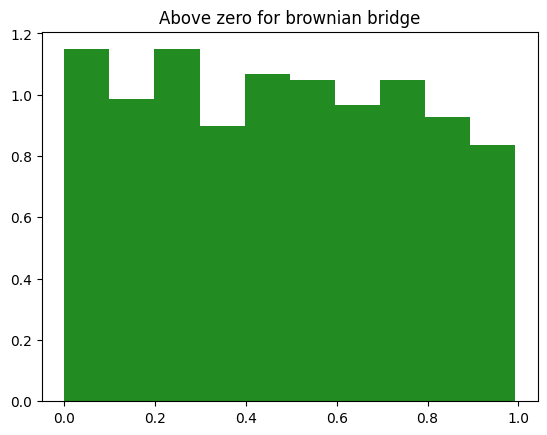

In [11]:
above_law_bm()